# Semana 13: K-Means y recomendación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
X, y_true = make_blobs(n_samples=180, centers=3, cluster_std=0.55, random_state=21)
print(X.shape)

(180, 2)


In [3]:
rows = []
models = {}
for k in [2, 3, 4, 5]:
    model = KMeans(n_clusters=k, n_init=10, random_state=21).fit(X)
    labels = model.labels_
    rows.append({"k": k, "inertia": model.inertia_, "silhouette": silhouette_score(X, labels)})
    models[k] = model
pd.DataFrame(rows)

,k,inertia,silhouette
0,2,1122.448010,0.782969
1,3,112.357747,0.852600
2,4,96.766073,0.693615
3,5,82.637050,0.508264


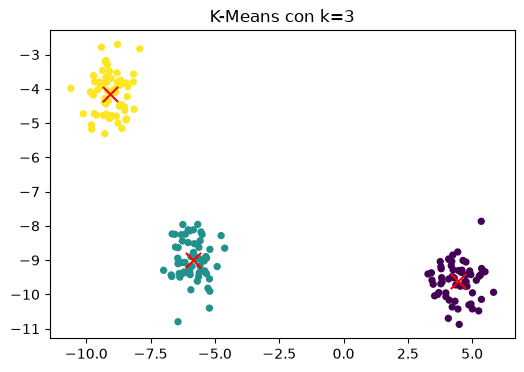

In [4]:
best = max(rows, key=lambda row: row["silhouette"])["k"]
model = models[best]
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X[:, 0], X[:, 1], c=model.labels_, s=18, cmap="viridis")
ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c="red", s=120, marker="x")
ax.set_title(f"K-Means con k={best}")
plt.close(fig)
fig

## Recomendación item-item

In [5]:
items = ["calculo", "algebra", "python", "estadistica", "visualizacion"]
M = np.array([
    [5, 4, 0, 1, 0],
    [4, 5, 0, 1, 0],
    [0, 1, 5, 4, 4],
    [1, 0, 4, 5, 4],
    [0, 0, 4, 4, 5],
], dtype=float)
sim = cosine_similarity(M)
pd.DataFrame(sim, index=items, columns=items)

,calculo,algebra,python,estadistica,visualizacion
calculo,1.000000,0.976190,0.162088,0.202610,0.081752
algebra,0.976190,1.000000,0.182349,0.182349,0.081752
python,0.162088,0.182349,1.000000,0.965517,0.973950
estadistica,0.202610,0.182349,0.965517,1.000000,0.973950
visualizacion,0.081752,0.081752,0.973950,0.973950,1.000000


In [6]:
def recommend(item_index, similarity, seen_items=None, top_k=2):
    seen = set() if seen_items is None else set(seen_items)
    seen.add(item_index)
    candidates = [idx for idx in range(similarity.shape[0]) if idx not in seen]
    candidates.sort(key=lambda idx: similarity[item_index, idx], reverse=True)
    return candidates[:top_k]

idx = items.index("python")
print([items[i] for i in recommend(idx, sim, seen_items={idx}, top_k=2)])

['visualizacion', 'estadistica']


## Cierre

Un cluster o una recomendación es una estructura candidata: requiere estabilidad, comparación y límites explícitos.

In [7]:
from sklearn.metrics import adjusted_rand_score

stability_rows = []
reference = KMeans(n_clusters=3, n_init=10, random_state=21).fit_predict(X)
for seed in [22, 23, 24, 25, 26]:
    labels = KMeans(n_clusters=3, n_init=1, random_state=seed).fit_predict(X)
    stability_rows.append({"seed": seed, "ARI_vs_reference": adjusted_rand_score(reference, labels)})
pd.DataFrame(stability_rows)

,seed,ARI_vs_reference
0,22,1.0
1,23,1.0
2,24,1.0
3,25,1.0
4,26,1.0


In [8]:
# Evaluación temporal mínima: la última interacción por usuario se oculta.
histories = [
    [(0, 1), (2, 2), (4, 3)],
    [(1, 1), (0, 2), (3, 3)],
    [(2, 1), (3, 2), (4, 3)],
]
train = np.zeros((len(histories), len(items)))
held_out = []
for u, history in enumerate(histories):
    for item, _time in history[:-1]: train[u, item] = 1
    held_out.append(history[-1][0])
item_sim = cosine_similarity(train.T)
popularity = train.sum(axis=0)
rows = []
for u in range(len(histories)):
    seen = set(np.flatnonzero(train[u]))
    scores = train[u] @ item_sim
    scores[list(seen)] = -np.inf
    rec = int(np.argmax(scores))
    pop = popularity.copy(); pop[list(seen)] = -np.inf
    rows.append({"user": u, "held_out": held_out[u], "item_item": rec, "popular": int(np.argmax(pop))})
pd.DataFrame(rows)

,user,held_out,item_item,popular
0,0,4,1,1
1,1,3,2,2
2,2,4,0,0
